#### Importing Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Importing Datasets

In [27]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test

#### KNN Regression

In [30]:
knn_regressor = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 10, 25, 50, 100, 500],  
    'weights': ['uniform', 'distance'] 
}

grid_search = GridSearchCV(estimator=knn_regressor, param_grid=param_grid, cv=5, verbose=2, scoring='neg_mean_squared_error')

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

grid_search.fit(Set1_X_Train_scaled, Set1_y_Train_array)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

best_knn_regressor = grid_search.best_estimator_

knn_pred_train = best_knn_regressor.predict(Set1_X_Train_scaled)
knn_pred_test = best_knn_regressor.predict(Set1_X_Test_scaled)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.7s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.7s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.7s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.7s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.7s
[CV] END ....................n_neighbors=10, weights=uniform; total time=   0.8s
[CV] END ....................n_neighbors=10, wei

#### KNN Evaluation

In [31]:
# Mean Squared Error
mse_train_knn = mean_squared_error(Set1_y_Train_array, knn_pred_train)
mse_test_knn = mean_squared_error(Set1_y_Test_array, knn_pred_test)

# Root Mean Squared Error
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)

# Mean Absolute Error
mae_train_knn = mean_absolute_error(Set1_y_Train_array, knn_pred_train)
mae_test_knn = mean_absolute_error(Set1_y_Test_array, knn_pred_test)

# R2 Score
r2_train_knn = r2_score(Set1_y_Train_array, knn_pred_train)
r2_test_knn = r2_score(Set1_y_Test_array, knn_pred_test)

# Coefficient of Determination
cod_train_knn = explained_variance_score(Set1_y_Train_array, knn_pred_train)
cod_test_knn = explained_variance_score(Set1_y_Test_array, knn_pred_test)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_knn)
print("Root Mean Squared Error:", rmse_train_knn)
print("Mean Absolute Error:", mae_train_knn)
print("R-squared Score:", r2_train_knn)
print("Coefficient of Determination:", cod_train_knn)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_knn)
print("Root Mean Squared Error:", rmse_test_knn)
print("Mean Absolute Error:", mae_test_knn)
print("R-squared Score:", r2_test_knn)
print("Coefficient of Determination:", cod_test_knn)

--Training Set Evaluation--
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared Score: 1.0
Coefficient of Determination: 1.0

--Testing Set Evaluation--
Mean Squared Error: 1221.2360829997751
Root Mean Squared Error: 34.94618839014886
Mean Absolute Error: 27.685082388924037
R-squared Score: 0.29280353131482806
Coefficient of Determination: 0.3289873898010819


#### Plot Evaluation Results

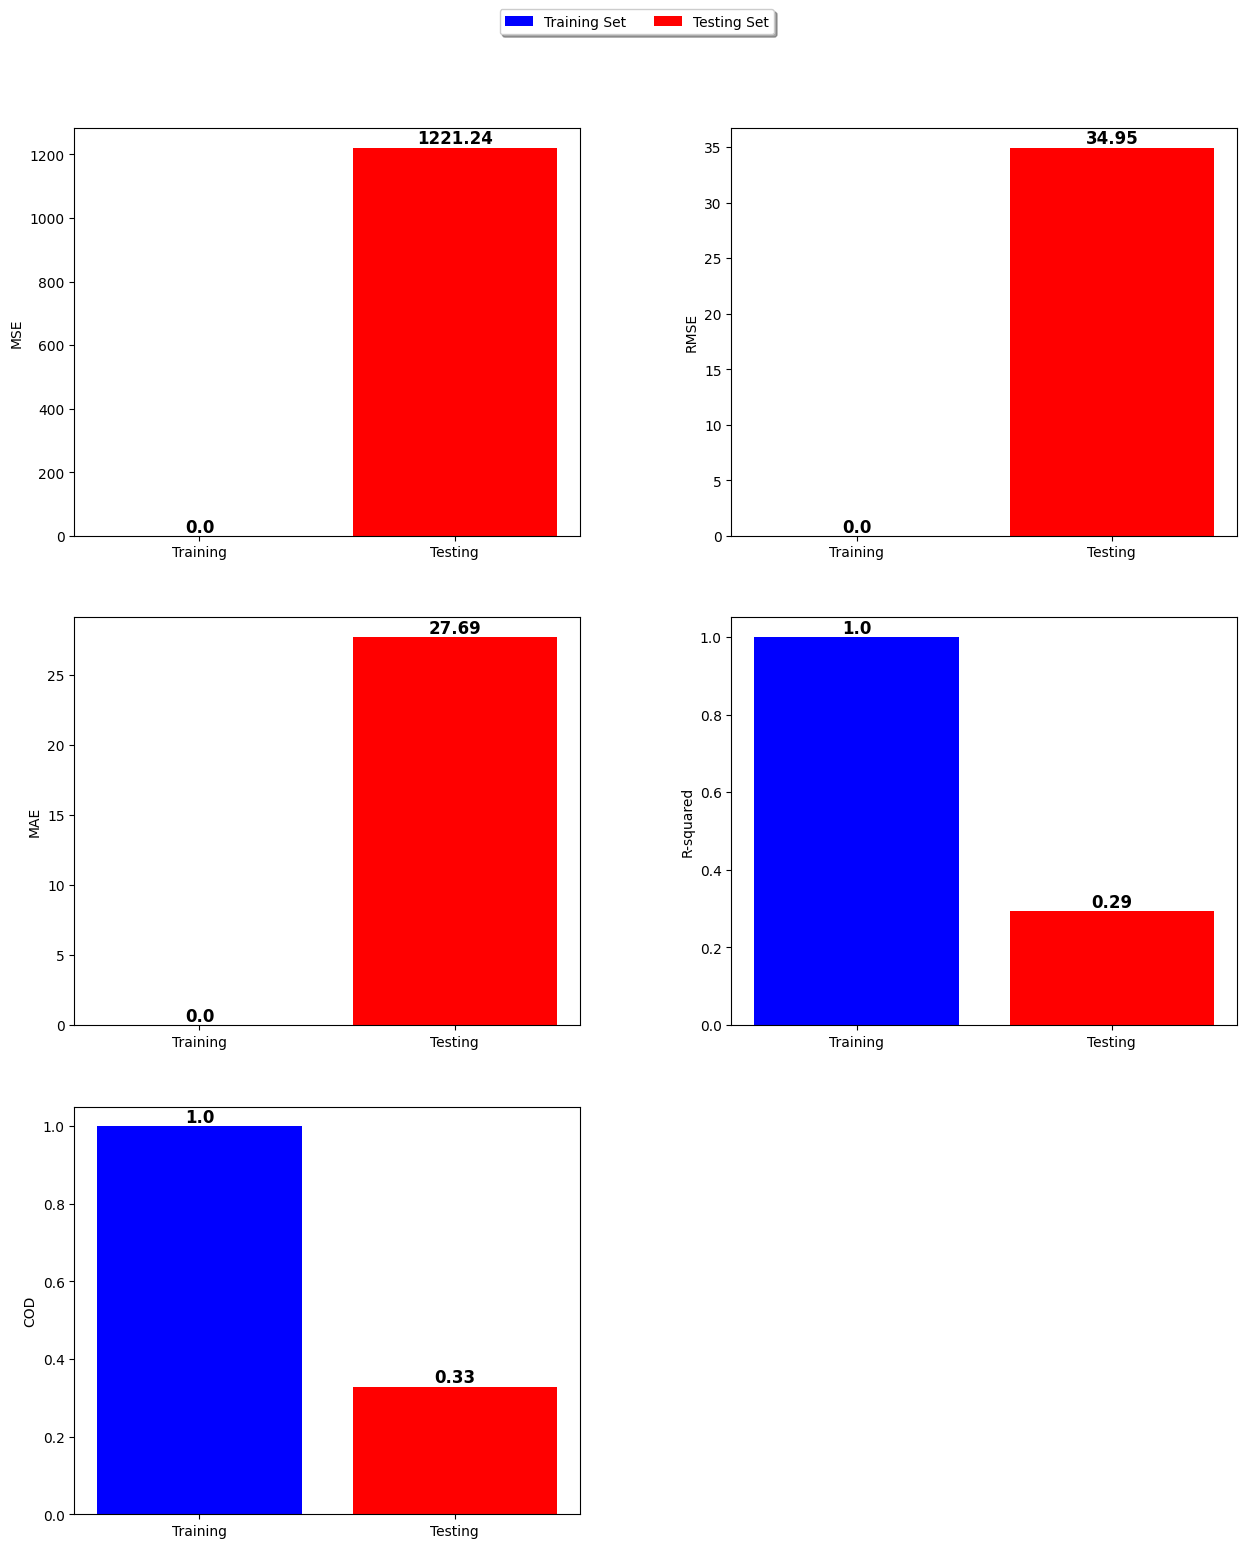

In [32]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_knn, rmse_train_knn, mae_train_knn, r2_train_knn, cod_train_knn]
test_metrics = [mse_test_knn, rmse_test_knn, mae_test_knn, r2_test_knn, cod_test_knn]

num_metrics = len(metrics)
num_cols = 2
num_rows = (num_metrics + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i // num_cols, i % num_cols]
    ax.bar('Training', train_metric, color='b', label='Training Set')
    ax.bar('Testing', test_metric, color='r', label='Testing Set')
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Position the legend in the middle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

for i in range(num_metrics, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.subplots_adjust(wspace=0.3)
plt.show()